In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf


df = pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/JDS/EXPL2/Chp11/superstore.csv')
print(df.head())
print(df.shape)
print(df.info())

   Row ID        Order ID Order Date Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   08-11-16  11-11-16    Second Class    CG-12520   
1       2  CA-2016-152156   08-11-16  11-11-16    Second Class    CG-12520   
2       3  CA-2016-138688   12-06-16  16-06-16    Second Class    DV-13045   
3       4  US-2015-108966   11-10-15  18-10-15  Standard Class    SO-20335   
4       5  US-2015-108966   11-10-15  18-10-15  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10001798

In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['order_date_year'] = df['Order Date'].apply(lambda x: x.year)
df['order_date_month'] = df['Order Date'].apply(lambda x: x.month)
df['order_date_year_month'] = df['Order Date'].apply(lambda x: x.strftime('%Y%m'))
df['order_date'] = df['Order Date'].apply(lambda x: x.strftime('%Y%m%d'))
df['order_date_day'] = df['Order Date'].apply(lambda x: x.day)
df['order_date_dayofweek'] = df['Order Date'].apply(lambda x: x.dayofweek)
df['order_date_dayofweek_name'] = df['Order Date'].apply(lambda x: x.strftime('%a'))

print(df.head())

/tmp/ipykernel_1643/2623913615.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


   Row ID        Order ID Order Date Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-08-11  11-11-16    Second Class    CG-12520   
1       2  CA-2016-152156 2016-08-11  11-11-16    Second Class    CG-12520   
2       3  CA-2016-138688 2016-12-06  16-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-11-10  18-10-15  Standard Class    SO-20335   
4       5  US-2015-108966 2015-11-10  18-10-15  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Quantity  \
0      Claire Gute   Consumer  United States        Henderson  ...        2   
1      Claire Gute   Consumer  United States        Henderson  ...        3   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...        2   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...        5   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...        2   

   Discount    Profit order_date_year order_date_month o

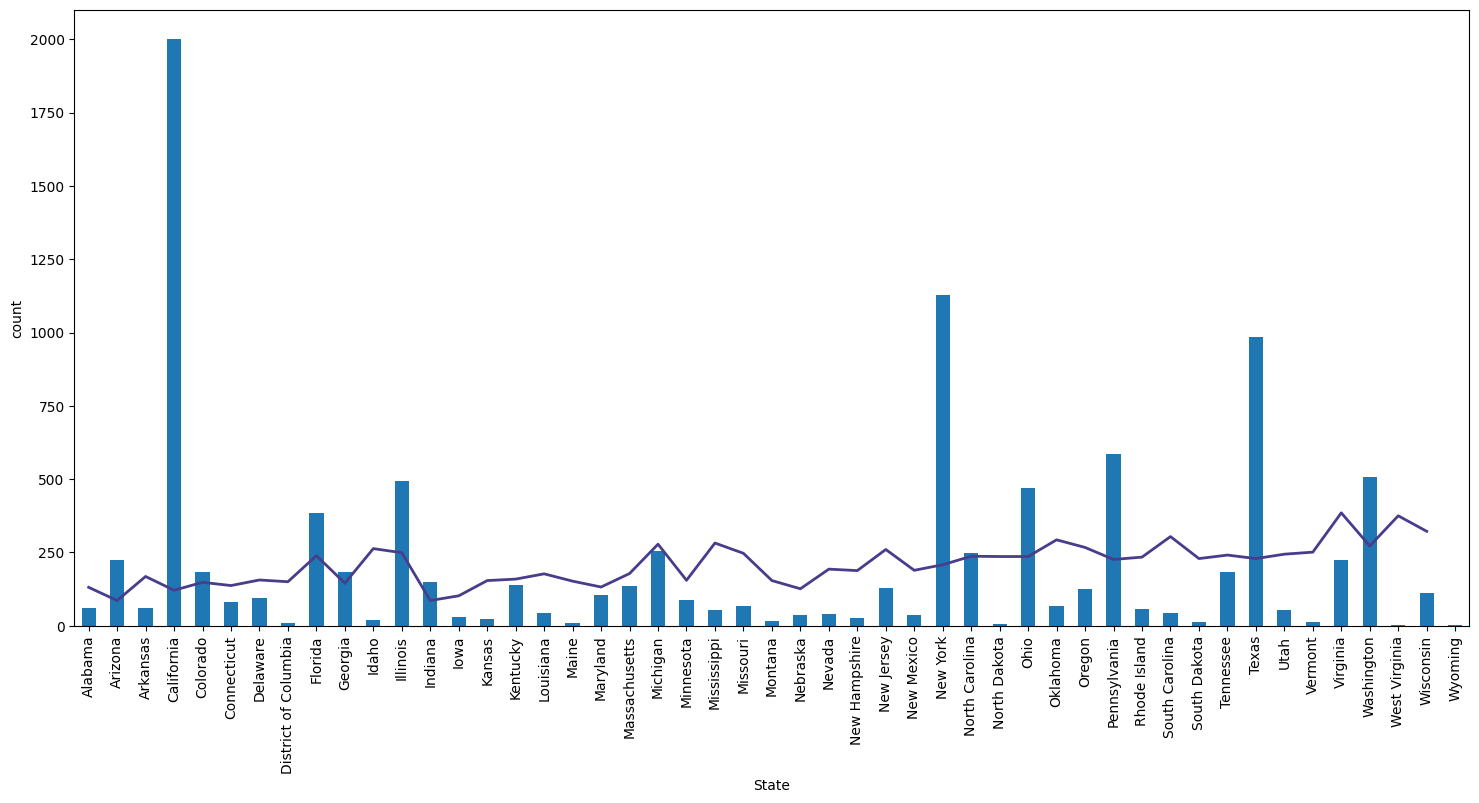

In [3]:
df.groupby('State').size().plot(kind='bar', figsize=(18,8))
sns.lineplot(data = df['order_date_year_month'].value_counts().sort_index(),color='darkslateblue', linewidth=2)
plt.show()

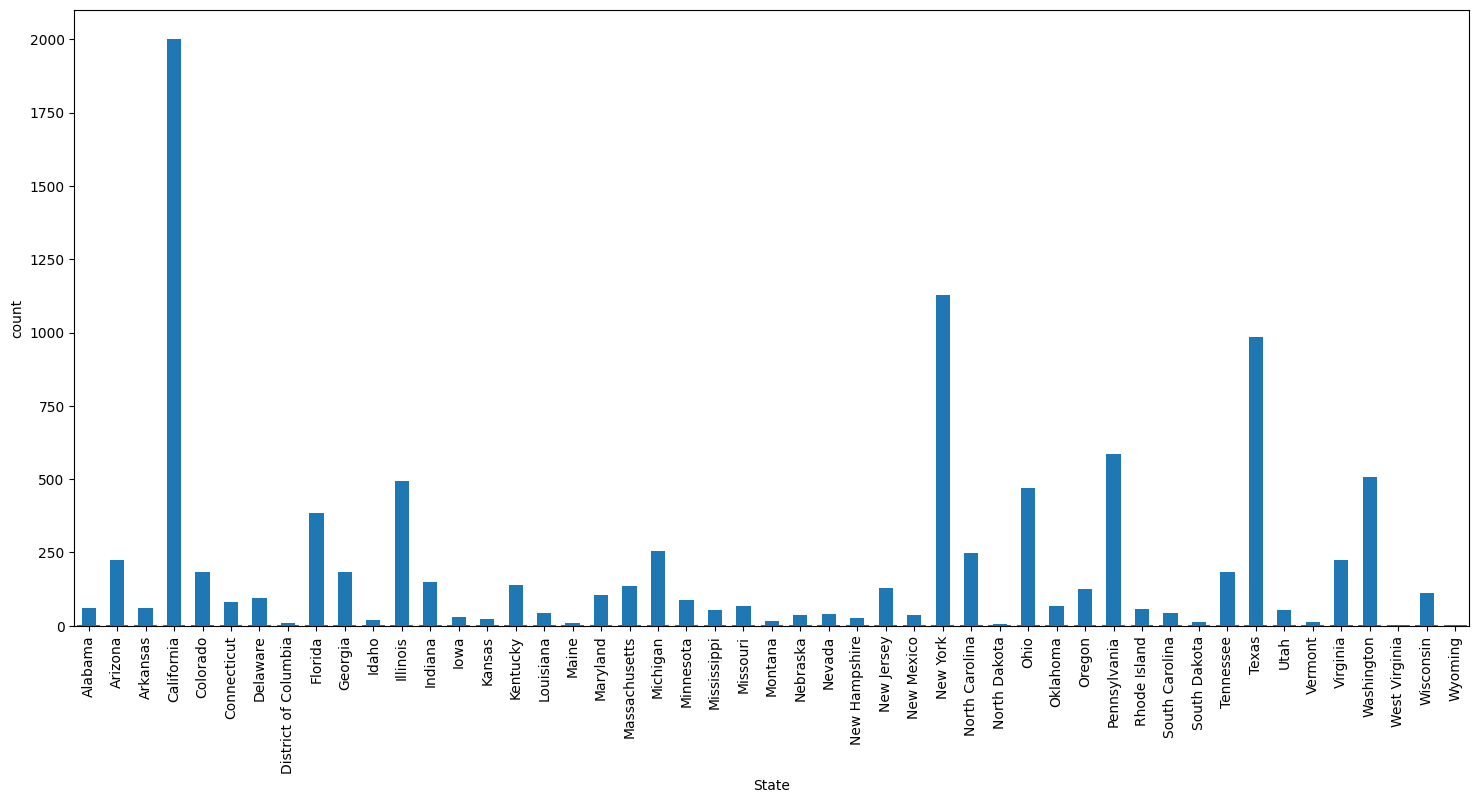

In [4]:
df.groupby('State').size().plot(kind='bar', figsize=(18,8))
sns.countplot(df.order_date_month)
plt.show()

In [5]:
city_sales = df[['City', 'Sales']]
city_sales = city_sales.sort_values(by='Sales', ascending=False)
print(city_sales.head(10))

               City      Sales
2697   Jacksonville  22638.480
6826      Lafayette  17499.950
8153        Seattle  13999.960
2623  New York City  11199.968
4190         Newark  10499.970
9039        Detroit   9892.740
4098    Minneapolis   9449.950
4277       Lakewood   9099.930
8488      Arlington   8749.950
6425   Philadelphia   8399.976


In [6]:
sales_data = df[['Order Date', 'Category', 'Sales']]
print(sales_data.head(10))

  Order Date         Category     Sales
0 2016-08-11        Furniture  261.9600
1 2016-08-11        Furniture  731.9400
2 2016-12-06  Office Supplies   14.6200
3 2015-11-10        Furniture  957.5775
4 2015-11-10  Office Supplies   22.3680
5 2014-09-06        Furniture   48.8600
6 2014-09-06  Office Supplies    7.2800
7 2014-09-06       Technology  907.1520
8 2014-09-06  Office Supplies   18.5040
9 2014-09-06  Office Supplies  114.9000


In [7]:
office_supplies = df.loc[df['Category'] == 'Office Supplies']
print('Oldest Order Date:', df['Order Date'].min())
print('Newest Order Date:', df['Order Date'].max())

Oldest Order Date: 2014-01-02 00:00:00
Newest Order Date: 2017-12-30 00:00:00


In [8]:
office_supplies = office_supplies[['Order Date', 'Sales']]
print(office_supplies.head())

  Order Date    Sales
2 2016-12-06   14.620
4 2015-11-10   22.368
6 2014-09-06    7.280
8 2014-09-06   18.504
9 2014-09-06  114.900


In [9]:
office_supplies = office_supplies.sort_values(by='Order Date')
office_supplies.groupby('Order Date')['Sales'].sum().reset_index()
office_supplies.set_index('Order Date', inplace=True)
print(office_supplies.head())

              Sales
Order Date         
2014-01-03   18.840
2014-01-03  129.552
2014-01-03  137.352
2014-01-03   17.472
2014-01-04   17.088


In [10]:
monthly_office = office_supplies['Sales'].resample('MS').mean()
print(monthly_office.head())

Order Date
2014-01-01    104.283407
2014-02-01     96.139800
2014-03-01     66.232554
2014-04-01    107.054506
2014-05-01    172.210340
Freq: MS, Name: Sales, dtype: float64


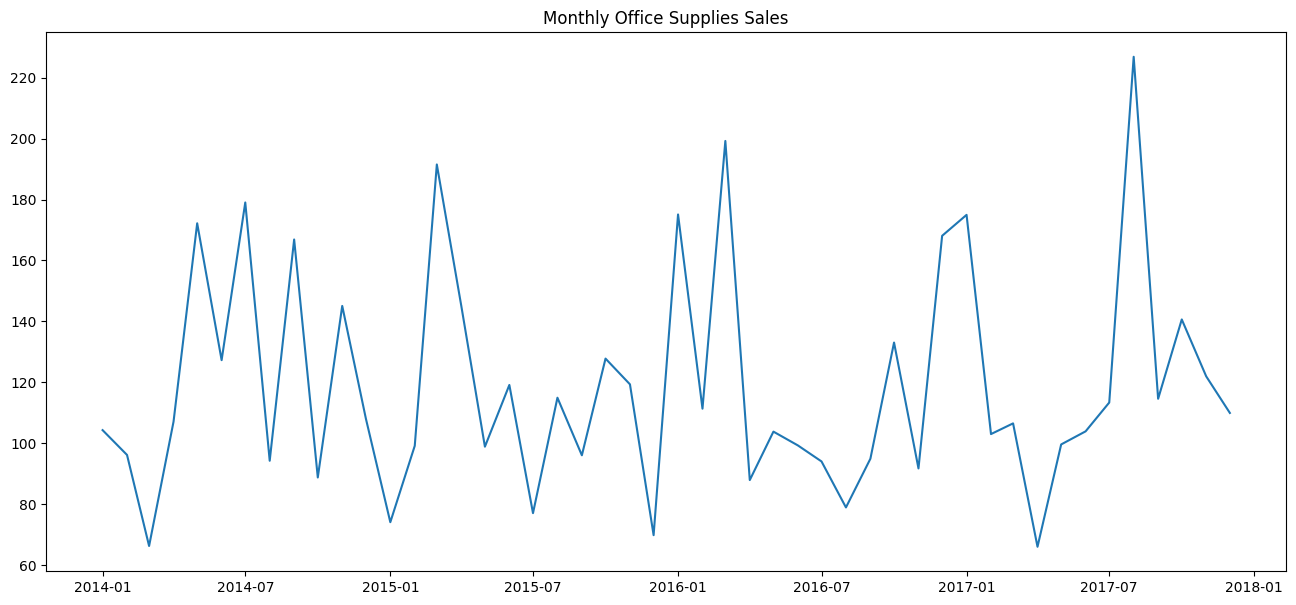

In [11]:
plt.figure(figsize=(16,7))
plt.plot(monthly_office)
plt.title('Monthly Office Supplies Sales')
plt.show()

In [12]:
furniture = df.loc[df['Category'] == 'Furniture']
furniture = furniture[['Order Date', 'Sales']]
print(furniture.head())

   Order Date      Sales
0  2016-08-11   261.9600
1  2016-08-11   731.9400
3  2015-11-10   957.5775
5  2014-09-06    48.8600
10 2014-09-06  1706.1840


In [13]:
furniture = furniture.sort_values(by='Order Date')
furniture.groupby('Order Date')['Sales'].sum().reset_index()
furniture.set_index('Order Date', inplace=True)
print(furniture.head())

              Sales
Order Date         
2014-01-03  362.250
2014-01-03   63.552
2014-01-03  376.509
2014-01-03  634.116
2014-01-03  457.568


In [14]:
monthly_furniture = furniture['Sales'].resample('MS').mean()
print(monthly_furniture.head())

Order Date
2014-01-01    366.856667
2014-02-01    158.120909
2014-03-01    436.729030
2014-04-01    273.087200
2014-05-01    254.646174
Freq: MS, Name: Sales, dtype: float64


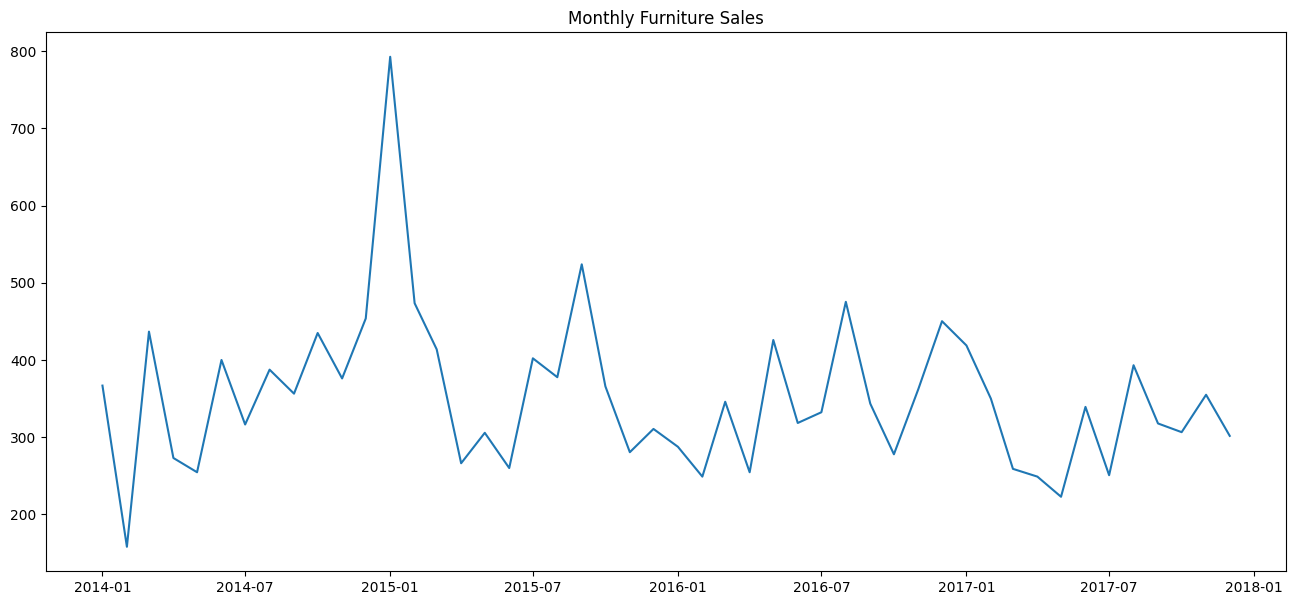

In [15]:
plt.figure(figsize=(16,7))
plt.plot(monthly_furniture)
plt.title('Monthly Furniture Sales')
plt.show()

In [16]:
tech_supplies = df.loc[df['Category'] == 'Technology']
tech_supplies = tech_supplies[['Order Date', 'Sales']]
print(tech_supplies.head())

   Order Date     Sales
7  2014-09-06   907.152
11 2014-09-06   911.424
19 2014-08-27   213.480
26 2016-01-16    90.570
35 2016-08-12  1097.544


In [17]:
tech_supplies = tech_supplies.sort_values(by='Order Date')
tech_supplies.groupby('Order Date')['Sales'].sum().reset_index()
tech_supplies.set_index('Order Date', inplace=True)
print(tech_supplies.head())

             Sales
Order Date        
2014-01-02  468.90
2014-01-03    5.94
2014-01-06  881.93
2014-01-07  575.92
2014-01-09  357.00


In [18]:
monthly_technology = tech_supplies['Sales'].resample('MS').mean()
print(monthly_technology.head())

Order Date
2014-01-01     494.145882
2014-02-01     247.871520
2014-03-01    1433.556609
2014-04-01     554.442941
2014-05-01     245.006452
Freq: MS, Name: Sales, dtype: float64


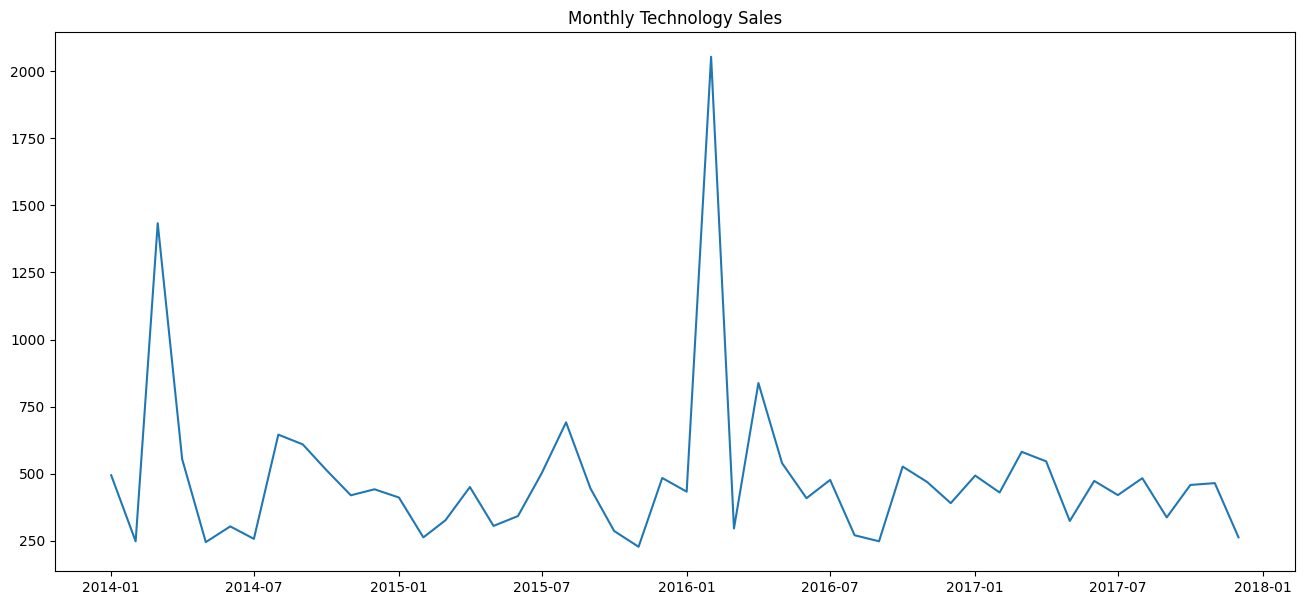

In [19]:
plt.figure(figsize=(16,7))
plt.plot(monthly_technology)
plt.title('Monthly Technology Sales')
plt.show()

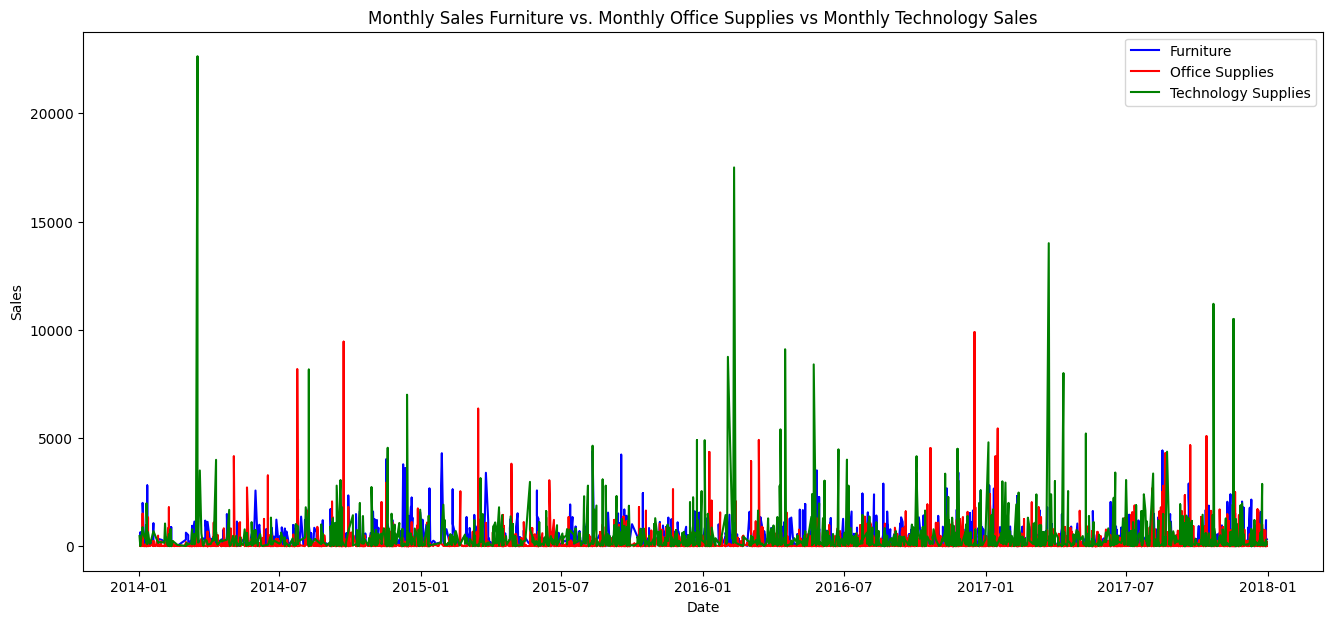

In [20]:
plt.figure(figsize = (16, 7))

plt.plot(furniture.index, furniture['Sales'], 'b-', label = 'Furniture')
plt.plot(office_supplies.index, office_supplies['Sales'], 'r-', label = 'Office Supplies')
plt.plot(tech_supplies.index, tech_supplies['Sales'], 'g-', label = 'Technology Supplies')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Monthly Sales Furniture vs. Monthly Office Supplies vs Monthly Technology Sales')
plt.legend()
plt.show()

In [21]:
furniture.rename(columns={'Sales': 'Furniture Sales'}, inplace=True)
office_supplies.rename(columns={'Sales': 'Office Sales'}, inplace=True)
tech_supplies.rename(columns={'Sales': 'Tech Sales'}, inplace=True)

In [22]:
store = furniture.merge(office_supplies, on='Order Date', how='inner').merge(tech_supplies, on='Order Date', how='inner')
print(store.head())

            Furniture Sales  Office Sales  Tech Sales
Order Date                                           
2014-01-03          362.250        18.840        5.94
2014-01-03          362.250       129.552        5.94
2014-01-03          362.250       137.352        5.94
2014-01-03          362.250        17.472        5.94
2014-01-03           63.552        18.840        5.94


(np.float64(-16.806923742698277), np.float64(1.2076797187270229e-29), 55, 43080, {'1%': np.float64(-3.430501803381847), '5%': np.float64(-2.861607093739644), '10%': np.float64(-2.566805711819969)}, np.float64(656806.1389456582))


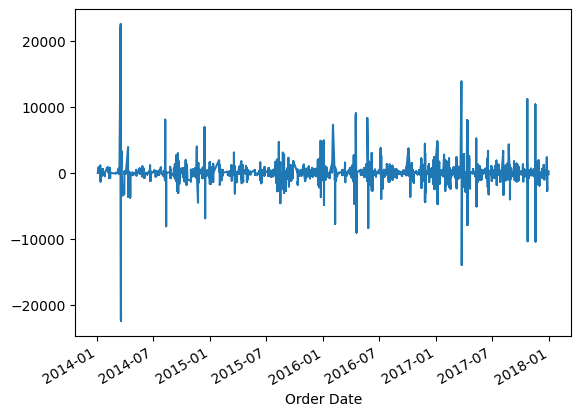

In [23]:
test_result = adfuller(store['Tech Sales'])
print(test_result)

store['First Difference Technology'] = store['Tech Sales'] - store['Tech Sales'].shift(1)
store['Seasonal First Difference Technology'] = store['Tech Sales'] - store['Tech Sales'].shift(12)
store['Seasonal First Difference Technology'].plot()
plt.show()

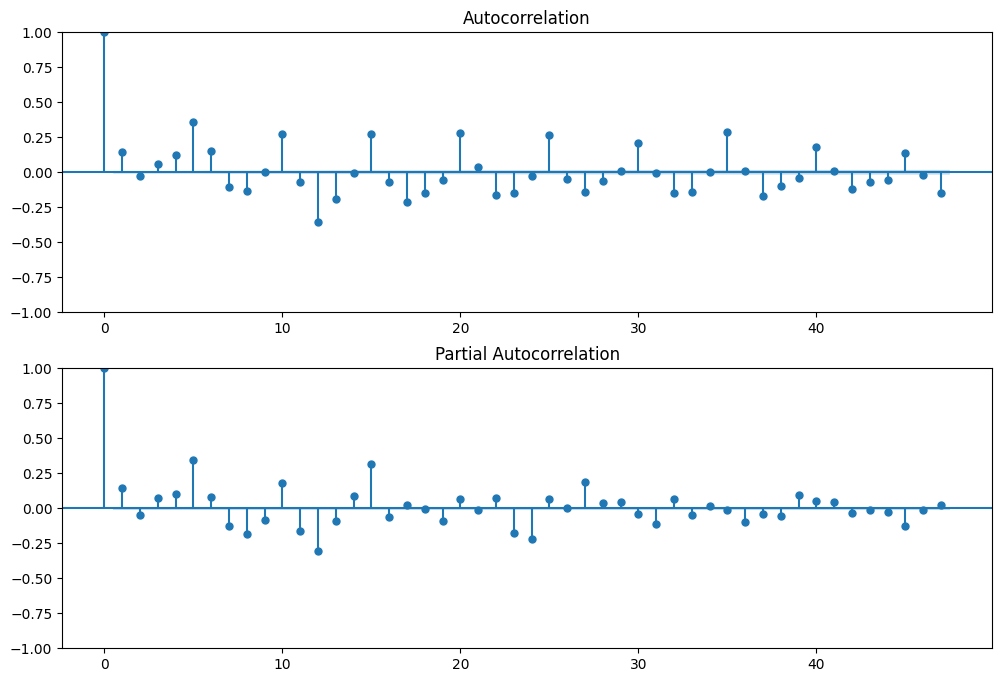

In [24]:
test_result = adfuller(store['Tech Sales'])
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(store['Seasonal First Difference Technology'].iloc[13:],ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(store['Seasonal First Difference Technology'].iloc[13:],ax=ax2)

In [ ]:
SarimaxModel = sm.tsa.statespace.SARIMAX(store['Tech Sales'], order = (1, 1, 1), seasonal_order =(1, 1, 2, 12))
SarimaxModel1 = SarimaxModel.fit()

store['Tech Forecast'] = SarimaxModel1.predict(start = 0, end = (len(store['Tech Sales'])) + 5, typ = 'levels')

plt.figure(figsize = (18, 5))
plt.plot(store.index, store['Tech Sales'], 'b-', label = 'Tech Sales')
plt.plot(store.index, store['Tech Forecast'], 'r-', label = 'Tech Forecast')

plt.title('Time Series Sales Forecast')
plt.legend()
plt.show()

(np.float64(-17.1607737126588), np.float64(6.84421346759367e-30), 55, 43080, {'1%': np.float64(-3.430501803381847), '5%': np.float64(-2.861607093739644), '10%': np.float64(-2.566805711819969)}, np.float64(596512.2951184973))


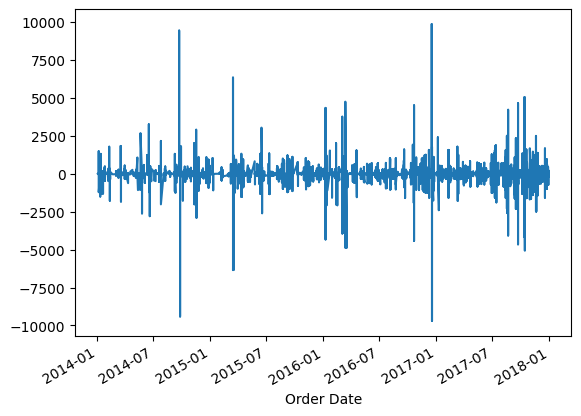

In [26]:
test_result = adfuller(store['Office Sales'])
print(test_result)
store['First Difference Office'] = store['Office Sales'] - store['Office Sales'].shift(1)
store['Seasonal First Difference Office'] = store['Office Sales'] - store['Office Sales'].shift(12)
store['Seasonal First Difference Office'].plot()
plt.show()

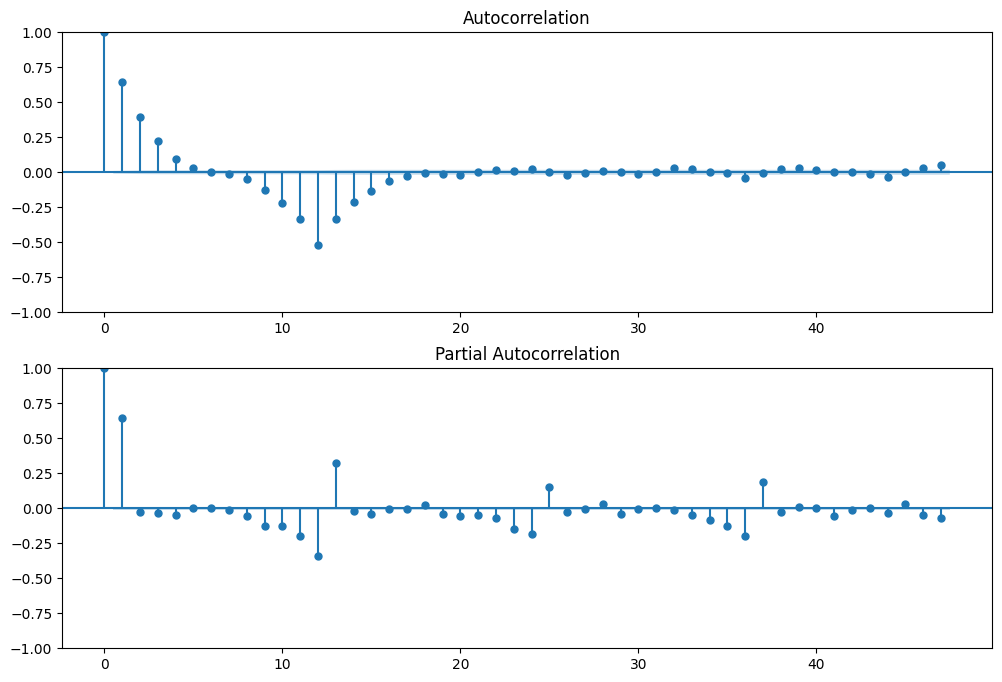

In [27]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(store['Seasonal First Difference Office'].iloc[13:],ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(store['Seasonal First Difference Office'].iloc[13:],ax=ax2)

In [ ]:
SarimaxModel = sm.tsa.statespace.SARIMAX(store['Office Sales'], order = (1, 1, 1), seasonal_order =(1, 1, 2, 12))
SarimaxModel1 = SarimaxModel.fit()

store['Office Forecast'] = SarimaxModel1.predict(start = 0, end = (len(store['Office Sales'])) + 5, typ = 'levels')

plt.figure(figsize = (18, 5))
plt.plot(store.index, store['Office Sales'], 'b-', label = 'Office Sales')
plt.plot(store.index, store['Office Forecast'], 'r-', label = 'Office Forecast')

plt.title('Time Series Sales Forecast')
plt.legend()
plt.show()

(np.float64(-20.862922334385097), 0.0, 36, 43099, {'1%': np.float64(-3.4305017364560233), '5%': np.float64(-2.861607064160665), '10%': np.float64(-2.566805696075907)}, np.float64(545498.7899792537))


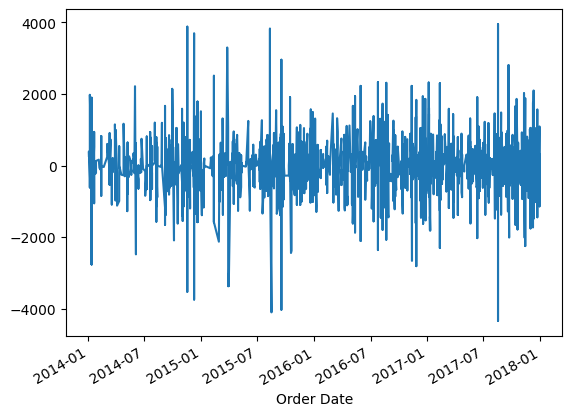

In [29]:
test_result = adfuller(store['Furniture Sales'])
print(test_result)
store['First Difference Furniture'] = store['Furniture Sales'] - store['Furniture Sales'].shift(1)
store['Seasonal First Difference Furniture'] = store['Furniture Sales'] - store['Furniture Sales'].shift(12)
store['Seasonal First Difference Furniture'].plot()
plt.show()

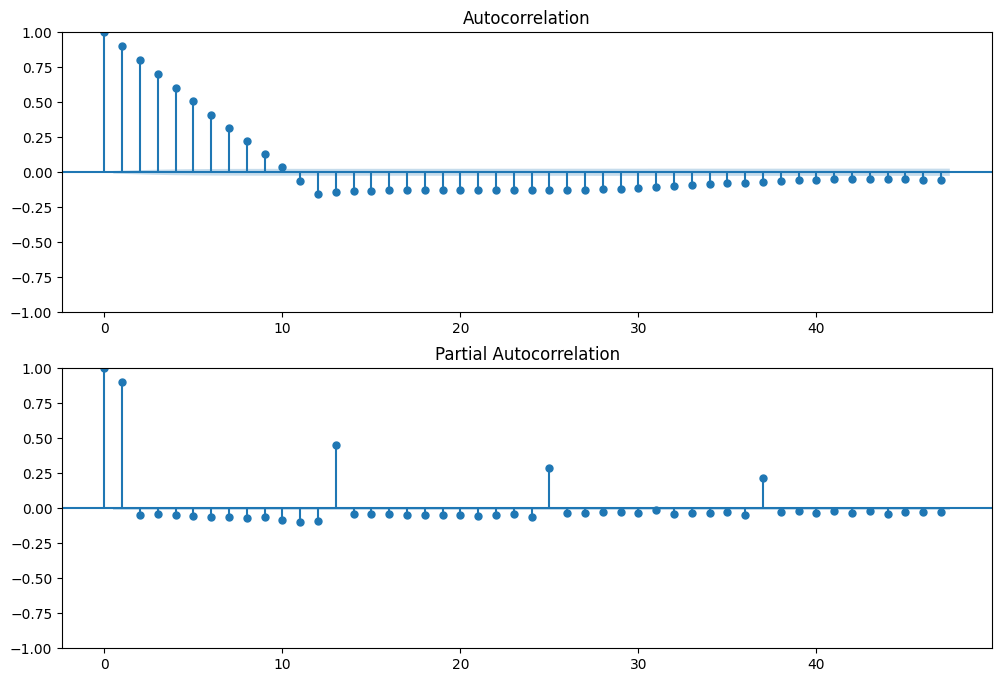

In [30]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(store['Seasonal First Difference Furniture'].iloc[13:],ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(store['Seasonal First Difference Furniture'].iloc[13:],ax=ax2)

In [ ]:
SarimaxModel = sm.tsa.statespace.SARIMAX(store['Furniture Sales'], order = (1, 1, 1), seasonal_order =(1, 1, 2, 12))
SarimaxModel1 = SarimaxModel.fit()

store['Furniture Forecast'] = SarimaxModel1.predict(start = 0, end = (len(store['Furniture Sales'])) + 5, typ = 'levels')

plt.figure(figsize = (18, 5))
plt.plot(store.index, store['Furniture Sales'], 'b-', label = 'Furniture Sales')
plt.plot(store.index, store['Furniture Forecast'], 'r-', label = 'Furniture Forecast')

plt.title('Time Series Sales Forecast')
plt.legend()
plt.show()